# 03 - Structural metrics: Exact Match and Component F1

How close the generated query is to the human-written gold as structure, on a shared canonical form (comments stripped, bindings alpha-renamed, keywords upper-cased). Exact Match is the strict binary floor (canonical strings identical); Component F1 decomposes each query into eight buckets (node labels, edge types, directions, WHERE, RETURN, ORDER, LIMIT, aggregations), scores each as a set F1, and macro-averages, so a translation is credited for getting the structure right even when the surface text differs. Both primitives live in the harness (`canonical.exact_match`, `components.component_f1`).

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "eval"))

import matplotlib.pyplot as plt
from harness import (
    FIGURES_DIR,
    METRICS_STRUCTURAL_CSV,
    RECORDS_DIR,
    frames,
    load_records,
    plots,
)
from harness.canonical import exact_match
from harness.components import component_f1

OUT_CSV = METRICS_STRUCTURAL_CSV
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Helper methods

The metric columns and the per-model table, per-target aggregation, and by-feature roll-up. All read the `struct_df` built below.

In [2]:
METRIC_COLS = ["exact_match", "component_f1_overall", "f1_node_labels", "f1_edge_types",
               "f1_directions", "f1_where", "f1_return", "f1_order", "f1_limit", "f1_aggregations"]
FEATURES = frames.feature_map("ldbc")


# Thin wrappers over harness.frames, so the per-model cells below stay query_results(target, model)
# and summary_by_model(target); the shared slicing/ordering/aggregation lives once in the harness.
def query_results(target, model):
    """Per-query structural metrics for one (target, model) cell."""
    return frames.query_results(struct_df, target, model, METRIC_COLS)


def summary_by_model(target):
    """Mean structural metrics for one target, by model (canonical order)."""
    return frames.summary_by_model(struct_df, target, METRIC_COLS)

## Prerequisites

**Identity sanity test**: every gold query scored against itself must give Exact Match true and Component F1 1.0. A failure means the canonicaliser has a bug, so the notebook aborts.

In [3]:
# Identity sanity test: every gold query scored against itself must be exact (EM True, F1 1.0),
# or canonicalisation / a component extractor has silently drifted.
frames.identity_check([
    ("exact_match", exact_match, True),
    ("component_f1", lambda t, e, tg: component_f1(t, e, tg)["overall"], 1.0),
])

Identity test: 45 cases; failures: 0
PASS


,dataset,query_id,target,exact_match,component_f1
0,ldbc,ldbc_q01,cypher,True,1.0
1,ldbc,ldbc_q01,aql,True,1.0
2,ldbc,ldbc_q01,gremlin,True,1.0
3,ldbc,ldbc_q02,cypher,True,1.0
4,ldbc,ldbc_q02,aql,True,1.0
5,ldbc,ldbc_q02,gremlin,True,1.0
6,ldbc,ldbc_q03,cypher,True,1.0
7,ldbc,ldbc_q03,aql,True,1.0
8,ldbc,ldbc_q03,gremlin,True,1.0
9,ldbc,ldbc_q04,cypher,True,1.0


## Compute components on the records

Score every translation against its gold; a missing translation (validation failure) scores zero across the board so it is never silently dropped.

In [4]:
def _structural(translated, expected, target):
    cf = component_f1(translated, expected, target)
    return {
        "exact_match": exact_match(translated, expected, target),
        "component_f1_overall": cf["overall"],
        **{f"f1_{k}": cf[k] for k in
           ["node_labels", "edge_types", "directions", "where", "return", "order", "limit", "aggregations"]},
    }


# A missing translation scores 0 on every component (and exact_match False), the worst case.
_missing = {"exact_match": False, **{c: 0.0 for c in METRIC_COLS if c != "exact_match"}}
struct_df = frames.compute_metrics_frame(load_records(RECORDS_DIR), _structural, _missing)
print(f"Computed structural metrics for {len(struct_df)} records.")

Computed structural metrics for 225 records.


## SQL to Cypher

### llama3.2:latest

In [5]:
query_results('cypher', 'llama3.2:latest')

,query_id,difficulty,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations
0,ldbc_q01,easy,True,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.0,1.000000
1,ldbc_q02,easy,False,0.767045,0.666667,1.0,0.000000,0.636364,0.833333,1.000000,1.0,1.000000
2,ldbc_q03,easy,False,0.708333,0.666667,1.0,0.000000,0.000000,1.000000,1.000000,1.0,1.000000
3,ldbc_q04,hard,False,0.988636,1.000000,1.0,1.000000,1.000000,0.909091,1.000000,1.0,1.000000
4,ldbc_q05,hard,False,0.617029,0.400000,1.0,0.000000,0.000000,0.869565,1.000000,1.0,0.666667
5,ldbc_q06,medium,False,0.812500,0.500000,1.0,0.000000,1.000000,1.000000,1.000000,1.0,1.000000
6,ldbc_q07,medium,False,0.827223,0.909091,1.0,0.400000,0.608696,0.700000,1.000000,1.0,1.000000
7,ldbc_q08,hard,False,0.664773,0.500000,1.0,0.000000,0.000000,0.818182,1.000000,1.0,1.000000
8,ldbc_q09,medium,False,0.810606,1.000000,1.0,1.000000,0.000000,0.818182,0.666667,1.0,1.000000
9,ldbc_q10,hard,False,0.896569,0.666667,1.0,1.000000,1.000000,0.705882,0.800000,1.0,1.000000


### qwen3-coder:30b

In [6]:
query_results('cypher', 'qwen3-coder:30b')

,query_id,difficulty,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations
0,ldbc_q01,easy,True,1.000000,1.00,1.0,1.000000,1.000000,1.000000,1.0,1.0,1.0
1,ldbc_q02,easy,True,1.000000,1.00,1.0,1.000000,1.000000,1.000000,1.0,1.0,1.0
2,ldbc_q03,easy,True,1.000000,1.00,1.0,1.000000,1.000000,1.000000,1.0,1.0,1.0
3,ldbc_q04,hard,False,0.972222,1.00,1.0,1.000000,1.000000,0.777778,1.0,1.0,1.0
4,ldbc_q05,hard,False,0.722222,1.00,1.0,0.000000,0.000000,0.777778,1.0,1.0,1.0
5,ldbc_q06,medium,False,0.975000,1.00,1.0,1.000000,1.000000,0.800000,1.0,1.0,1.0
6,ldbc_q07,medium,False,0.926136,1.00,1.0,0.500000,0.909091,1.000000,1.0,1.0,1.0
7,ldbc_q08,hard,False,0.963636,1.00,1.0,1.000000,0.800000,0.909091,1.0,1.0,1.0
8,ldbc_q09,medium,False,0.802083,0.75,1.0,0.666667,0.000000,1.000000,1.0,1.0,1.0
9,ldbc_q10,hard,False,0.875000,1.00,1.0,0.000000,1.000000,1.000000,1.0,1.0,1.0


### gemma4:26b

In [7]:
query_results('cypher', 'gemma4:26b')

,query_id,difficulty,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations
0,ldbc_q01,easy,True,1.000000,1.0,1.0,1.00,1.000000,1.000000,1.0,1.0,1.0
1,ldbc_q02,easy,True,1.000000,1.0,1.0,1.00,1.000000,1.000000,1.0,1.0,1.0
2,ldbc_q03,easy,True,1.000000,1.0,1.0,1.00,1.000000,1.000000,1.0,1.0,1.0
3,ldbc_q04,hard,True,1.000000,1.0,1.0,1.00,1.000000,1.000000,1.0,1.0,1.0
4,ldbc_q05,hard,False,0.838636,1.0,1.0,0.00,0.800000,0.909091,1.0,1.0,1.0
5,ldbc_q06,medium,True,1.000000,1.0,1.0,1.00,1.000000,1.000000,1.0,1.0,1.0
6,ldbc_q07,medium,False,0.926136,1.0,1.0,0.50,0.909091,1.000000,1.0,1.0,1.0
7,ldbc_q08,hard,True,1.000000,1.0,1.0,1.00,1.000000,1.000000,1.0,1.0,1.0
8,ldbc_q09,medium,False,1.000000,1.0,1.0,1.00,1.000000,1.000000,1.0,1.0,1.0
9,ldbc_q10,hard,True,1.000000,1.0,1.0,1.00,1.000000,1.000000,1.0,1.0,1.0


### claude-opus-4-8

In [8]:
query_results('cypher', 'claude-opus-4-8')

,query_id,difficulty,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations
0,ldbc_q01,easy,True,1.000000,1.0,1.0,1.00,1.000000,1.000000,1.0,1.0,1.0
1,ldbc_q02,easy,True,1.000000,1.0,1.0,1.00,1.000000,1.000000,1.0,1.0,1.0
2,ldbc_q03,easy,True,1.000000,1.0,1.0,1.00,1.000000,1.000000,1.0,1.0,1.0
3,ldbc_q04,hard,False,0.988636,1.0,1.0,1.00,1.000000,0.909091,1.0,1.0,1.0
4,ldbc_q05,hard,False,0.838636,1.0,1.0,0.00,0.800000,0.909091,1.0,1.0,1.0
5,ldbc_q06,medium,True,1.000000,1.0,1.0,1.00,1.000000,1.000000,1.0,1.0,1.0
6,ldbc_q07,medium,False,0.926136,1.0,1.0,0.50,0.909091,1.000000,1.0,1.0,1.0
7,ldbc_q08,hard,True,1.000000,1.0,1.0,1.00,1.000000,1.000000,1.0,1.0,1.0
8,ldbc_q09,medium,False,1.000000,1.0,1.0,1.00,1.000000,1.000000,1.0,1.0,1.0
9,ldbc_q10,hard,False,1.000000,1.0,1.0,1.00,1.000000,1.000000,1.0,1.0,1.0


### claude-opus-4-8-thinking

In [9]:
query_results('cypher', 'claude-opus-4-8-thinking')

,query_id,difficulty,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations,thinking_used
0,ldbc_q01,easy,True,1.000000,1.0,1.0,1.0,1.000000,1.000000,1.0,1.0,1.0,False
1,ldbc_q02,easy,True,1.000000,1.0,1.0,1.0,1.000000,1.000000,1.0,1.0,1.0,True
2,ldbc_q03,easy,False,0.875000,1.0,1.0,1.0,0.000000,1.000000,1.0,1.0,1.0,False
3,ldbc_q04,hard,False,0.988636,1.0,1.0,1.0,1.000000,0.909091,1.0,1.0,1.0,False
4,ldbc_q05,hard,False,0.838636,1.0,1.0,0.0,0.800000,0.909091,1.0,1.0,1.0,True
5,ldbc_q06,medium,True,1.000000,1.0,1.0,1.0,1.000000,1.000000,1.0,1.0,1.0,False
6,ldbc_q07,medium,False,0.926136,1.0,1.0,0.5,0.909091,1.000000,1.0,1.0,1.0,False
7,ldbc_q08,hard,False,0.963636,1.0,1.0,1.0,0.800000,0.909091,1.0,1.0,1.0,True
8,ldbc_q09,medium,True,1.000000,1.0,1.0,1.0,1.000000,1.000000,1.0,1.0,1.0,True
9,ldbc_q10,hard,True,1.000000,1.0,1.0,1.0,1.000000,1.000000,1.0,1.0,1.0,False


### Aggregation by model

In [10]:
summary_by_model('cypher')

,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations
model,,,,,,,,,,
llama3.2:latest,0.066667,0.823287,0.773853,1.0,0.548889,0.546496,0.874833,0.931111,0.933333,0.977778
qwen3-coder:30b,0.266667,0.925120,0.953333,1.0,0.760317,0.780606,0.906705,1.000000,1.000000,1.000000
gemma4:26b,0.666667,0.981477,1.000000,1.0,0.883333,0.980606,0.987879,1.000000,1.000000,1.000000
claude-opus-4-8,0.533333,0.980390,1.000000,1.0,0.883333,0.980606,0.979183,1.000000,1.000000,1.000000
claude-opus-4-8-thinking,0.533333,0.971161,1.000000,1.0,0.900000,0.900606,0.968678,1.000000,1.000000,1.000000


### Figures

In [11]:
sub = struct_df[struct_df["target"] == 'cypher']
label = 'SQL -> Cypher'
prefix = 'cypher'

#### Component F1 per model

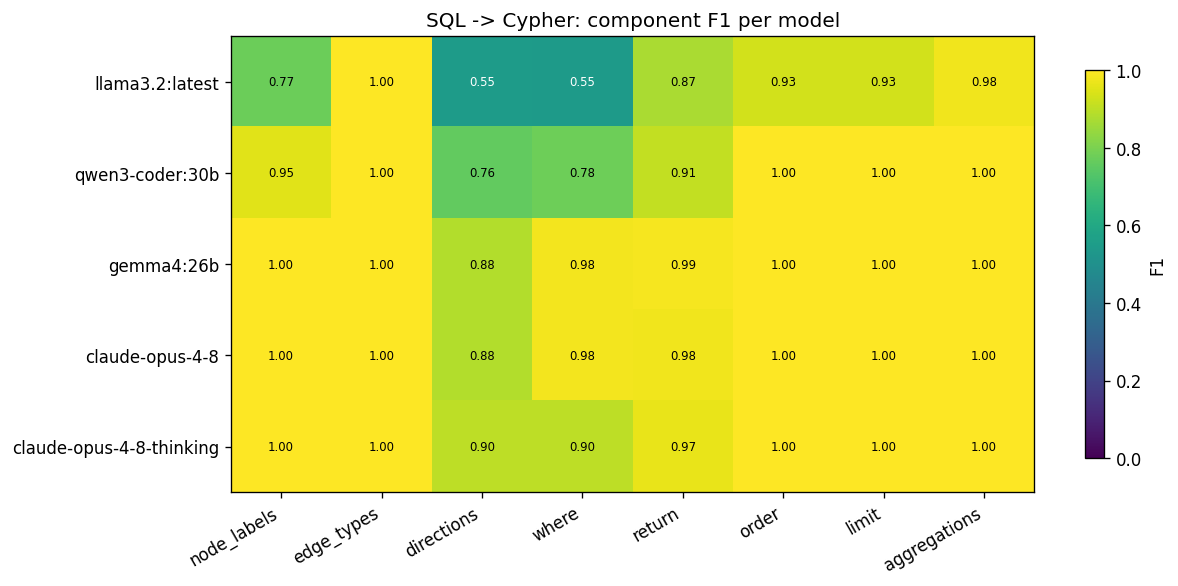

In [12]:
p = FIGURES_DIR / f"{prefix}_component_f1.png"
plots.component_f1_by_model(sub, path=p, title=f"{label}: component F1 per model")
plots.show(p)
plt.close("all")

#### Component F1 by query x model

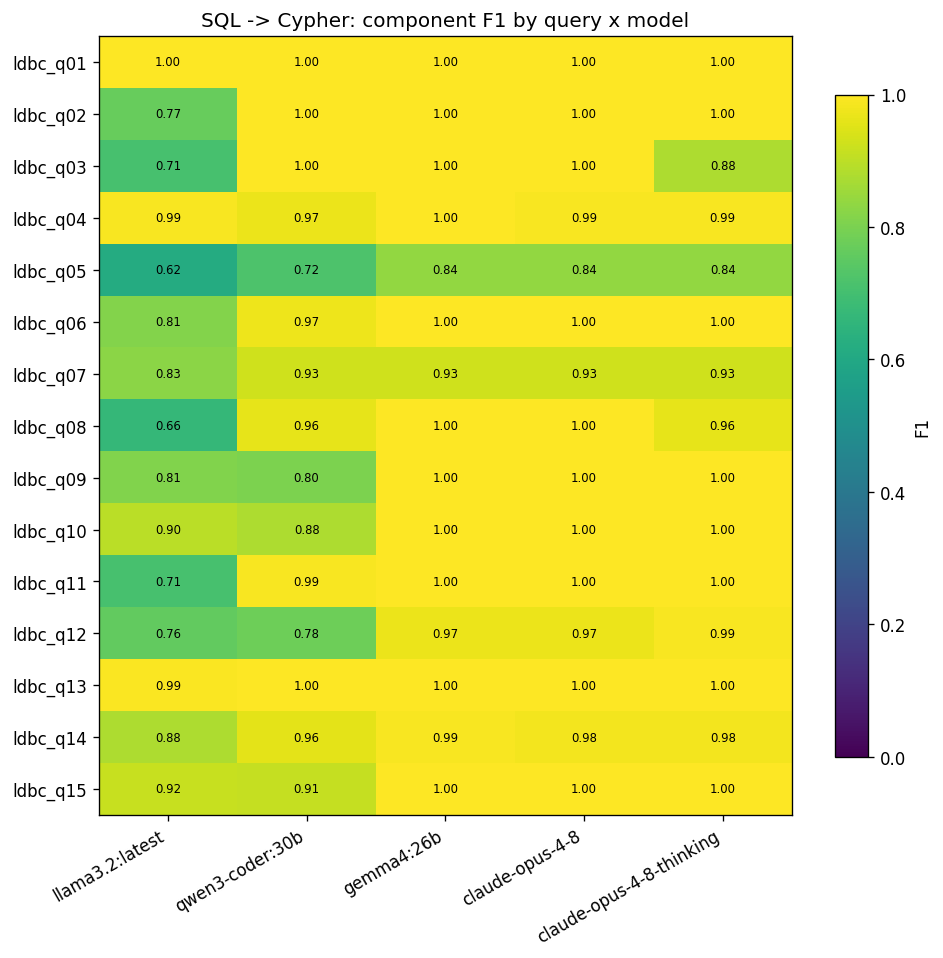

In [13]:
p = FIGURES_DIR / f"{prefix}_query_model_f1.png"
plots.query_model_heatmap(sub, "component_f1_overall", p, title=f"{label}: component F1 by query x model", cbar_label="F1")
plots.show(p)
plt.close("all")

#### Exact match and Component F1 per model

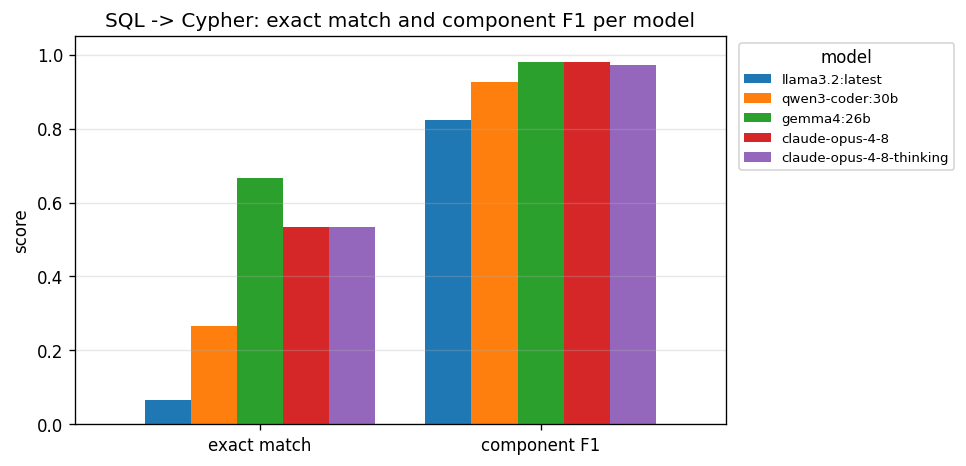

In [14]:
p = FIGURES_DIR / f"{prefix}_structural_bars.png"
plots.per_model_bars(sub, ["exact_match", "component_f1_overall"], p, title=f"{label}: exact match and component F1 per model", ylabel="score", labels={"exact_match": "exact match", "component_f1_overall": "component F1"})
plots.show(p)
plt.close("all")

## SQL to AQL

### llama3.2:latest

In [15]:
query_results('aql', 'llama3.2:latest')

,query_id,difficulty,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations
0,ldbc_q01,easy,False,0.875000,0.0,1.0,1.000000,1.000000,1.000000,1.000000,1.0,1.0
1,ldbc_q02,easy,False,0.625000,0.0,0.0,0.000000,1.000000,1.000000,1.000000,1.0,1.0
2,ldbc_q03,easy,False,0.850000,0.0,1.0,1.000000,0.800000,1.000000,1.000000,1.0,1.0
3,ldbc_q04,hard,False,0.537500,0.0,0.0,1.000000,0.000000,0.800000,0.500000,1.0,1.0
4,ldbc_q05,hard,False,0.454246,0.0,0.0,0.000000,0.315789,0.818182,0.500000,1.0,1.0
5,ldbc_q06,medium,False,0.679487,0.0,0.0,0.666667,1.000000,0.769231,1.000000,1.0,1.0
6,ldbc_q07,medium,False,0.834135,0.0,1.0,1.000000,0.750000,0.923077,1.000000,1.0,1.0
7,ldbc_q08,hard,False,0.331863,0.0,0.0,0.400000,0.666667,0.588235,0.000000,0.0,1.0
8,ldbc_q09,medium,False,0.499282,0.0,0.0,0.000000,0.500000,0.827586,0.666667,1.0,1.0
9,ldbc_q10,hard,False,0.416667,0.0,0.0,1.000000,0.000000,0.833333,0.500000,0.0,1.0


### qwen3-coder:30b

In [16]:
query_results('aql', 'qwen3-coder:30b')

,query_id,difficulty,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations
0,ldbc_q01,easy,False,0.985000,1.000000,1.000000,1.000000,1.000000,0.880000,1.000000,1.0,1.0
1,ldbc_q02,easy,False,0.993421,1.000000,1.000000,1.000000,1.000000,0.947368,1.000000,1.0,1.0
2,ldbc_q03,easy,False,0.962500,1.000000,1.000000,1.000000,0.800000,0.900000,1.000000,1.0,1.0
3,ldbc_q04,hard,False,0.725379,0.666667,1.000000,1.000000,0.000000,0.636364,0.500000,1.0,1.0
4,ldbc_q05,hard,False,0.618659,0.666667,1.000000,0.000000,0.000000,0.782609,0.500000,1.0,1.0
5,ldbc_q06,medium,False,0.980769,1.000000,1.000000,1.000000,1.000000,0.846154,1.000000,1.0,1.0
6,ldbc_q07,medium,False,0.890476,0.666667,0.800000,0.800000,1.000000,0.857143,1.000000,1.0,1.0
7,ldbc_q08,hard,False,0.895008,0.666667,0.800000,0.888889,0.947368,0.857143,1.000000,1.0,1.0
8,ldbc_q09,medium,False,0.676365,0.000000,0.666667,0.666667,0.500000,0.827586,0.750000,1.0,1.0
9,ldbc_q10,hard,False,0.879762,0.666667,1.000000,1.000000,1.000000,0.800000,0.571429,1.0,1.0


### gemma4:26b

In [17]:
query_results('aql', 'gemma4:26b')

,query_id,difficulty,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations
0,ldbc_q01,easy,True,1.000000,1.000000,1.0,1.0,1.000,1.000000,1.000000,1.0,1.0
1,ldbc_q02,easy,True,1.000000,1.000000,1.0,1.0,1.000,1.000000,1.000000,1.0,1.0
2,ldbc_q03,easy,True,1.000000,1.000000,1.0,1.0,1.000,1.000000,1.000000,1.0,1.0
3,ldbc_q04,hard,False,0.720833,0.666667,1.0,1.0,1.000,0.600000,0.500000,1.0,0.0
4,ldbc_q05,hard,False,0.883333,0.666667,1.0,1.0,0.400,1.000000,1.000000,1.0,1.0
5,ldbc_q06,medium,False,0.990385,1.000000,1.0,1.0,1.000,0.923077,1.000000,1.0,1.0
6,ldbc_q07,medium,False,0.958333,0.666667,1.0,1.0,1.000,1.000000,1.000000,1.0,1.0
7,ldbc_q08,hard,False,0.793155,0.666667,1.0,1.0,0.750,0.928571,1.000000,1.0,0.0
8,ldbc_q09,medium,False,0.712823,0.000000,1.0,0.5,0.625,0.827586,0.750000,1.0,1.0
9,ldbc_q10,hard,False,0.873106,0.666667,1.0,1.0,1.000,0.818182,0.500000,1.0,1.0


### claude-opus-4-8

In [18]:
query_results('aql', 'claude-opus-4-8')

,query_id,difficulty,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations
0,ldbc_q01,easy,False,0.985000,1.000000,1.0,1.000000,1.000000,0.880000,1.000000,1.0,1.0
1,ldbc_q02,easy,True,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.0,1.0
2,ldbc_q03,easy,False,0.975000,1.000000,1.0,1.000000,0.800000,1.000000,1.000000,1.0,1.0
3,ldbc_q04,hard,False,0.879762,0.666667,1.0,1.000000,1.000000,0.800000,0.571429,1.0,1.0
4,ldbc_q05,hard,False,0.780118,0.666667,1.0,0.666667,0.625000,0.782609,0.500000,1.0,1.0
5,ldbc_q06,medium,False,0.990385,1.000000,1.0,1.000000,1.000000,0.923077,1.000000,1.0,1.0
6,ldbc_q07,medium,False,0.949405,0.666667,1.0,1.000000,1.000000,0.928571,1.000000,1.0,1.0
7,ldbc_q08,hard,False,0.949405,0.666667,1.0,1.000000,1.000000,0.928571,1.000000,1.0,1.0
8,ldbc_q09,medium,False,0.712823,0.000000,1.0,0.500000,0.625000,0.827586,0.750000,1.0,1.0
9,ldbc_q10,hard,False,0.879762,0.666667,1.0,1.000000,1.000000,0.800000,0.571429,1.0,1.0


### claude-opus-4-8-thinking

In [19]:
query_results('aql', 'claude-opus-4-8-thinking')

,query_id,difficulty,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations,thinking_used
0,ldbc_q01,easy,False,0.985000,1.000000,1.0,1.0,1.000000,0.880000,1.000000,1.0,1.0,True
1,ldbc_q02,easy,False,0.993421,1.000000,1.0,1.0,1.000000,0.947368,1.000000,1.0,1.0,True
2,ldbc_q03,easy,False,0.987500,1.000000,1.0,1.0,1.000000,0.900000,1.000000,1.0,1.0,True
3,ldbc_q04,hard,False,0.879762,0.666667,1.0,1.0,1.000000,0.800000,0.571429,1.0,1.0,True
4,ldbc_q05,hard,False,0.927083,0.666667,1.0,1.0,0.750000,1.000000,1.000000,1.0,1.0,True
5,ldbc_q06,medium,False,0.990385,1.000000,1.0,1.0,1.000000,0.923077,1.000000,1.0,1.0,True
6,ldbc_q07,medium,False,0.949405,0.666667,1.0,1.0,1.000000,0.928571,1.000000,1.0,1.0,True
7,ldbc_q08,hard,False,0.949405,0.666667,1.0,1.0,1.000000,0.928571,1.000000,1.0,1.0,True
8,ldbc_q09,medium,False,0.877694,0.500000,1.0,1.0,0.625000,0.896552,1.000000,1.0,1.0,True
9,ldbc_q10,hard,False,0.879762,0.666667,1.0,1.0,1.000000,0.800000,0.571429,1.0,1.0,True


### Aggregation by model

In [20]:
summary_by_model('aql')

,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations
model,,,,,,,,,,
llama3.2:latest,0.000000,0.547494,0.000000,0.200000,0.626667,0.470138,0.825368,0.724444,0.733333,0.800000
qwen3-coder:30b,0.000000,0.821752,0.622222,0.837778,0.880847,0.678713,0.814929,0.806190,1.000000,0.933333
gemma4:26b,0.200000,0.875839,0.648889,0.933333,0.966667,0.785000,0.904870,0.901282,1.000000,0.866667
claude-opus-4-8,0.066667,0.883675,0.648889,0.933333,0.944444,0.825556,0.863999,0.853175,1.000000,1.000000
claude-opus-4-8-thinking,0.000000,0.901117,0.682222,0.933333,1.000000,0.802778,0.876321,0.914286,1.000000,1.000000


### Figures

In [21]:
sub = struct_df[struct_df["target"] == 'aql']
label = 'SQL -> AQL'
prefix = 'aql'

#### Component F1 per model

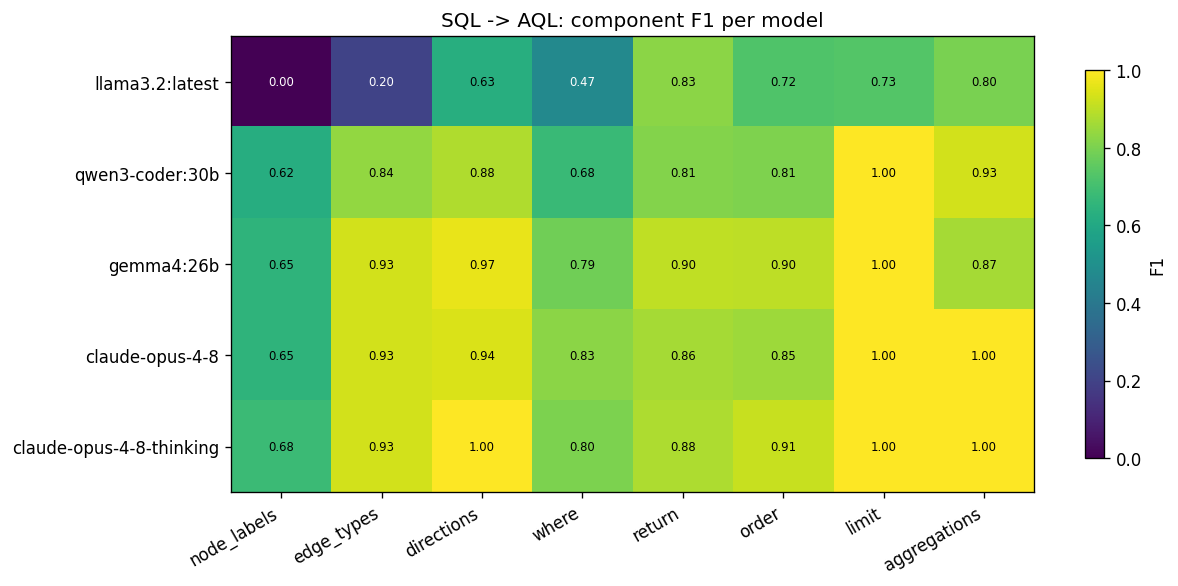

In [22]:
p = FIGURES_DIR / f"{prefix}_component_f1.png"
plots.component_f1_by_model(sub, path=p, title=f"{label}: component F1 per model")
plots.show(p)
plt.close("all")

#### Component F1 by query x model

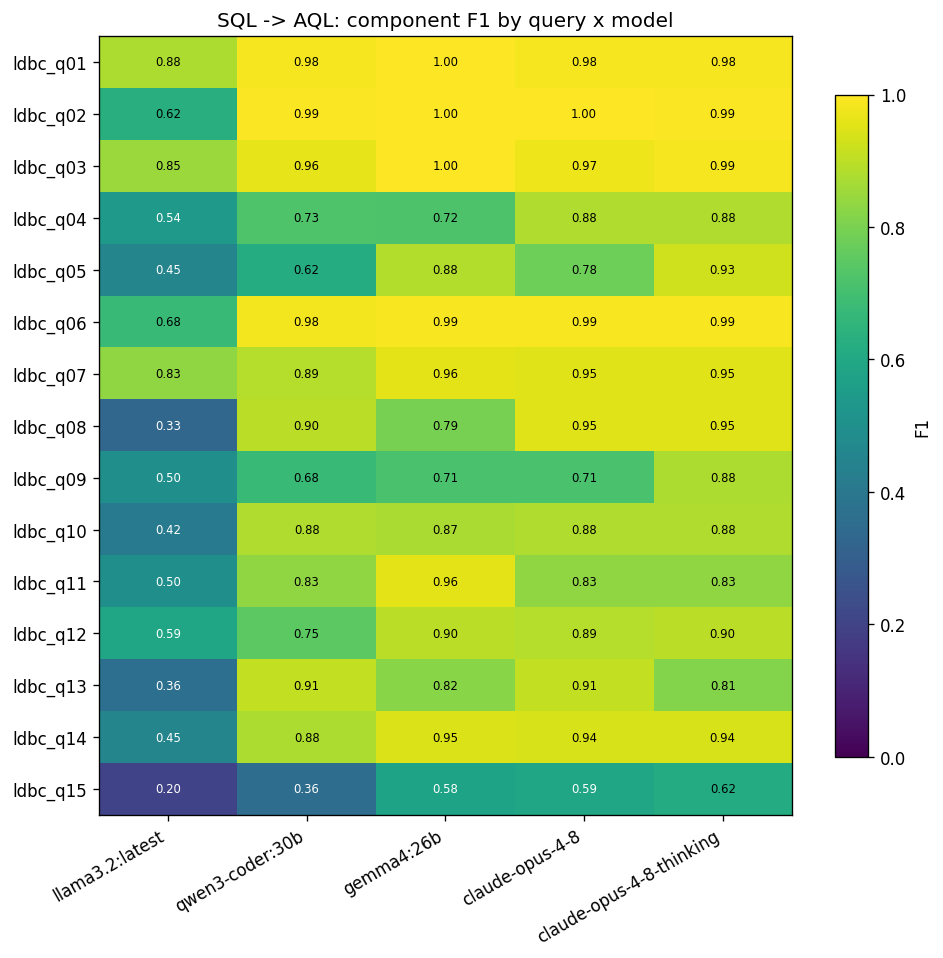

In [23]:
p = FIGURES_DIR / f"{prefix}_query_model_f1.png"
plots.query_model_heatmap(sub, "component_f1_overall", p, title=f"{label}: component F1 by query x model", cbar_label="F1")
plots.show(p)
plt.close("all")

#### Exact match and Component F1 per model

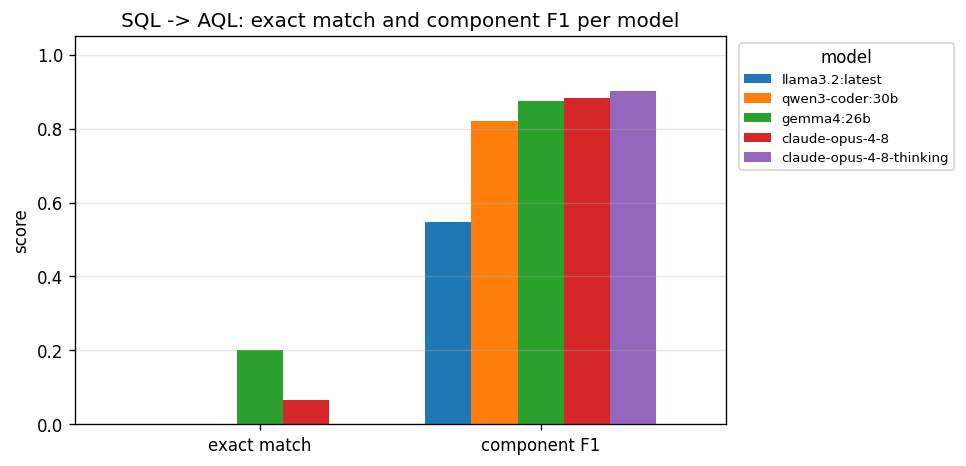

In [24]:
p = FIGURES_DIR / f"{prefix}_structural_bars.png"
plots.per_model_bars(sub, ["exact_match", "component_f1_overall"], p, title=f"{label}: exact match and component F1 per model", ylabel="score", labels={"exact_match": "exact match", "component_f1_overall": "component F1"})
plots.show(p)
plt.close("all")

## SQL to Gremlin

### llama3.2:latest

In [25]:
query_results('gremlin', 'llama3.2:latest')

,query_id,difficulty,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations
0,ldbc_q01,easy,False,0.800000,0.000000,1.000000,1.000000,0.400000,1.000000,1.000000,1.0,1.000000
1,ldbc_q02,easy,False,0.821429,0.666667,1.000000,1.000000,0.571429,0.333333,1.000000,1.0,1.000000
2,ldbc_q03,easy,False,0.843750,0.000000,1.000000,1.000000,0.750000,1.000000,1.000000,1.0,1.000000
3,ldbc_q04,hard,False,0.669981,0.000000,1.000000,0.500000,0.500000,0.818182,0.875000,1.0,0.666667
4,ldbc_q05,hard,False,0.578010,0.500000,0.500000,0.400000,0.000000,0.608696,0.615385,1.0,1.000000
5,ldbc_q06,medium,False,0.728291,0.000000,1.000000,0.666667,0.571429,0.588235,1.000000,1.0,1.000000
6,ldbc_q07,medium,False,0.541667,0.000000,0.000000,0.666667,0.583333,0.083333,1.000000,1.0,1.000000
7,ldbc_q08,hard,False,0.636497,0.000000,0.800000,0.500000,0.315789,0.476190,1.000000,1.0,1.000000
8,ldbc_q09,medium,False,0.608967,0.000000,0.800000,0.800000,0.750000,0.521739,0.000000,1.0,1.000000
9,ldbc_q10,hard,False,0.734848,1.000000,1.000000,0.666667,1.000000,0.666667,0.545455,1.0,0.000000


### qwen3-coder:30b

In [26]:
query_results('gremlin', 'qwen3-coder:30b')

,query_id,difficulty,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations
0,ldbc_q01,easy,False,0.975000,1.000000,1.000000,1.000000,1.000000,0.800000,1.000000,1.0,1.000000
1,ldbc_q02,easy,False,0.937500,1.000000,1.000000,1.000000,1.000000,0.500000,1.000000,1.0,1.000000
2,ldbc_q03,easy,False,0.957143,1.000000,1.000000,1.000000,0.857143,0.800000,1.000000,1.0,1.000000
3,ldbc_q04,hard,False,0.748868,1.000000,1.000000,0.666667,0.000000,0.782609,0.875000,1.0,0.666667
4,ldbc_q05,hard,False,0.706374,1.000000,1.000000,0.000000,1.000000,0.620690,0.363636,1.0,0.666667
5,ldbc_q06,medium,False,0.940789,1.000000,1.000000,1.000000,1.000000,0.526316,1.000000,1.0,1.000000
6,ldbc_q07,medium,False,0.945000,1.000000,1.000000,1.000000,1.000000,0.560000,1.000000,1.0,1.000000
7,ldbc_q08,hard,False,0.835602,1.000000,1.000000,0.750000,0.814815,0.120000,1.000000,1.0,1.000000
8,ldbc_q09,medium,False,0.744449,0.666667,0.666667,0.666667,0.571429,0.838710,0.545455,1.0,1.000000
9,ldbc_q10,hard,False,0.911458,1.000000,1.000000,0.500000,1.000000,0.916667,0.875000,1.0,1.000000


### gemma4:26b

In [27]:
query_results('gremlin', 'gemma4:26b')

,query_id,difficulty,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations
0,ldbc_q01,easy,False,0.957143,1.000000,1.0,1.000000,0.857143,0.800000,1.000000,1.0,1.0
1,ldbc_q02,easy,False,0.937500,1.000000,1.0,1.000000,1.000000,0.500000,1.000000,1.0,1.0
2,ldbc_q03,easy,False,0.982143,1.000000,1.0,1.000000,0.857143,1.000000,1.000000,1.0,1.0
3,ldbc_q04,hard,False,0.943182,1.000000,1.0,1.000000,1.000000,1.000000,0.545455,1.0,1.0
4,ldbc_q05,hard,False,0.800476,1.000000,1.0,0.666667,0.000000,0.880000,0.857143,1.0,1.0
5,ldbc_q06,medium,False,0.955357,1.000000,1.0,1.000000,0.857143,0.785714,1.000000,1.0,1.0
6,ldbc_q07,medium,False,0.979167,1.000000,1.0,1.000000,1.000000,0.833333,1.000000,1.0,1.0
7,ldbc_q08,hard,False,0.975806,1.000000,1.0,1.000000,0.903226,0.903226,1.000000,1.0,1.0
8,ldbc_q09,medium,False,0.751962,0.666667,1.0,0.500000,0.428571,0.875000,0.545455,1.0,1.0
9,ldbc_q10,hard,False,0.943182,1.000000,1.0,1.000000,1.000000,1.000000,0.545455,1.0,1.0


### claude-opus-4-8

In [28]:
query_results('gremlin', 'claude-opus-4-8')

,query_id,difficulty,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations
0,ldbc_q01,easy,False,0.975000,1.0,1.0,1.000000,1.000000,0.800000,1.000000,1.0,1.0
1,ldbc_q02,easy,False,0.933824,1.0,1.0,1.000000,1.000000,0.470588,1.000000,1.0,1.0
2,ldbc_q03,easy,False,0.957143,1.0,1.0,1.000000,0.857143,0.800000,1.000000,1.0,1.0
3,ldbc_q04,hard,False,0.833333,1.0,1.0,0.666667,0.000000,1.000000,1.000000,1.0,1.0
4,ldbc_q05,hard,False,0.922500,0.5,1.0,1.000000,1.000000,0.880000,1.000000,1.0,1.0
5,ldbc_q06,medium,False,0.940789,1.0,1.0,1.000000,1.000000,0.526316,1.000000,1.0,1.0
6,ldbc_q07,medium,False,0.982143,1.0,1.0,1.000000,1.000000,0.857143,1.000000,1.0,1.0
7,ldbc_q08,hard,False,0.950513,1.0,1.0,1.000000,0.967742,0.636364,1.000000,1.0,1.0
8,ldbc_q09,medium,False,0.786932,1.0,1.0,0.500000,0.500000,0.750000,0.545455,1.0,1.0
9,ldbc_q10,hard,True,1.000000,1.0,1.0,1.000000,1.000000,1.000000,1.000000,1.0,1.0


### claude-opus-4-8-thinking

In [29]:
query_results('gremlin', 'claude-opus-4-8-thinking')

,query_id,difficulty,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations,thinking_used
0,ldbc_q01,easy,False,0.975000,1.0,1.0,1.0,1.000000,0.800000,1.000000,1.0,1.0,False
1,ldbc_q02,easy,False,0.933824,1.0,1.0,1.0,1.000000,0.470588,1.000000,1.0,1.0,True
2,ldbc_q03,easy,False,0.957143,1.0,1.0,1.0,0.857143,0.800000,1.000000,1.0,1.0,False
3,ldbc_q04,hard,False,0.838235,1.0,1.0,1.0,0.000000,1.000000,0.705882,1.0,1.0,True
4,ldbc_q05,hard,False,0.762500,1.0,1.0,0.5,0.000000,1.000000,0.600000,1.0,1.0,True
5,ldbc_q06,medium,False,0.976852,1.0,1.0,1.0,1.000000,0.814815,1.000000,1.0,1.0,True
6,ldbc_q07,medium,False,0.982143,1.0,1.0,1.0,1.000000,0.857143,1.000000,1.0,1.0,True
7,ldbc_q08,hard,False,0.983871,1.0,1.0,1.0,0.967742,0.903226,1.000000,1.0,1.0,True
8,ldbc_q09,medium,False,0.849653,1.0,1.0,0.5,0.533333,0.875000,0.888889,1.0,1.0,True
9,ldbc_q10,hard,True,1.000000,1.0,1.0,1.0,1.000000,1.000000,1.000000,1.0,1.0,True


### Aggregation by model

In [30]:
summary_by_model('gremlin')

,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations
model,,,,,,,,,,
llama3.2:latest,0.000000,0.653274,0.144444,0.784444,0.693333,0.444568,0.645898,0.802389,1.0,0.711111
qwen3-coder:30b,0.000000,0.826638,0.911111,0.864444,0.746825,0.782526,0.640019,0.868182,1.0,0.800000
gemma4:26b,0.000000,0.909241,0.977778,1.000000,0.922222,0.847182,0.836699,0.823377,1.0,0.866667
claude-opus-4-8,0.066667,0.907426,0.966667,1.000000,0.911111,0.862929,0.701947,0.950089,1.0,0.866667
claude-opus-4-8-thinking,0.066667,0.905003,1.000000,1.000000,0.900000,0.808008,0.805304,0.860044,1.0,0.866667


### Figures

In [31]:
sub = struct_df[struct_df["target"] == 'gremlin']
label = 'SQL -> Gremlin'
prefix = 'gremlin'

#### Component F1 per model

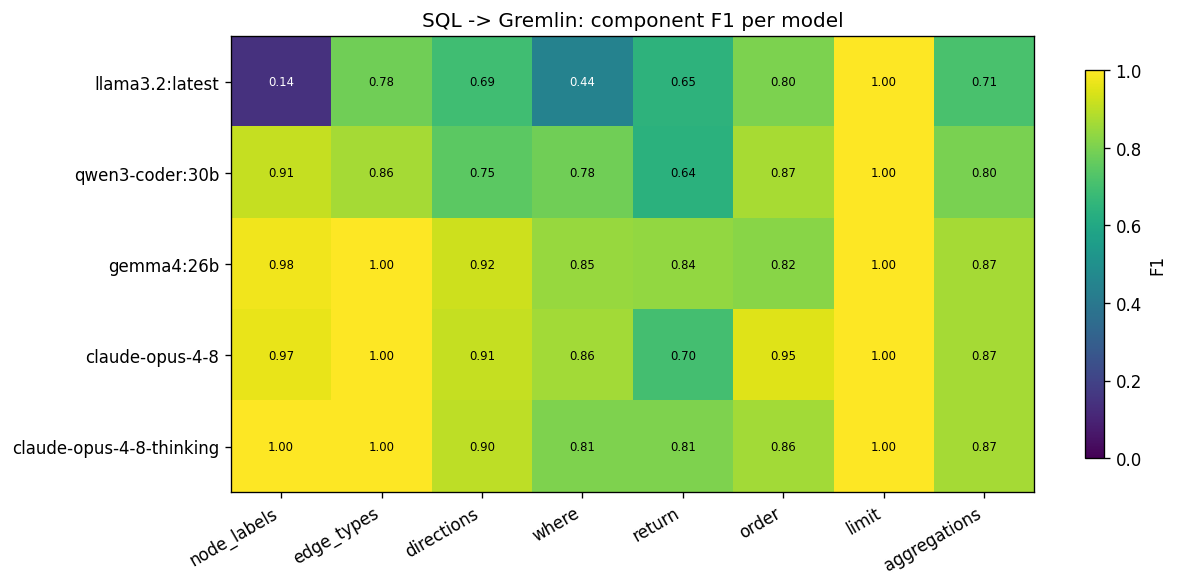

In [32]:
p = FIGURES_DIR / f"{prefix}_component_f1.png"
plots.component_f1_by_model(sub, path=p, title=f"{label}: component F1 per model")
plots.show(p)
plt.close("all")

#### Component F1 by query x model

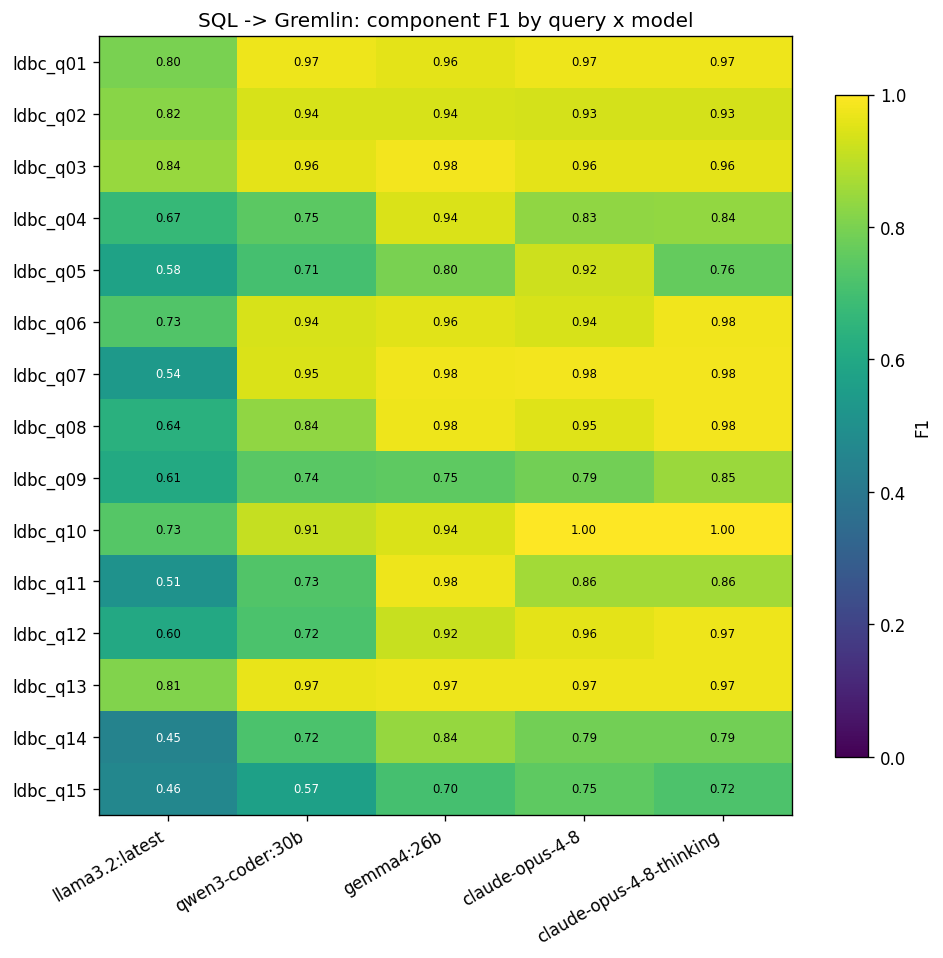

In [33]:
p = FIGURES_DIR / f"{prefix}_query_model_f1.png"
plots.query_model_heatmap(sub, "component_f1_overall", p, title=f"{label}: component F1 by query x model", cbar_label="F1")
plots.show(p)
plt.close("all")

#### Exact match and Component F1 per model

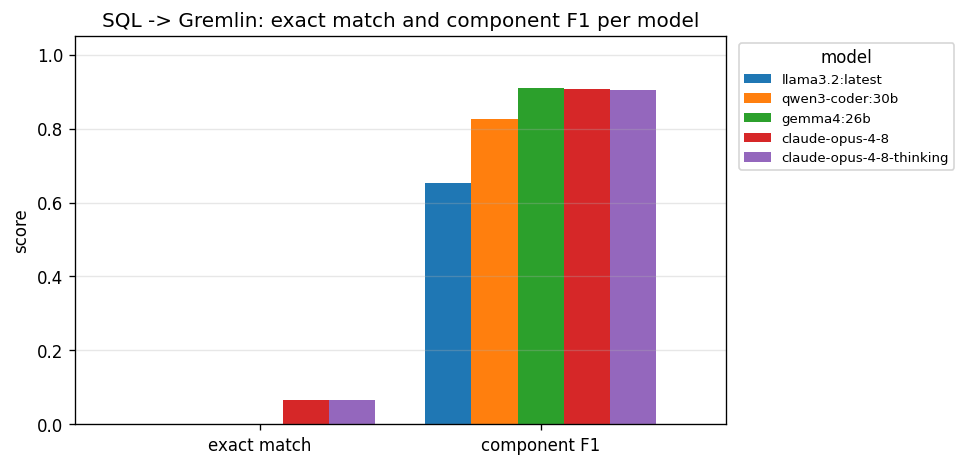

In [34]:
p = FIGURES_DIR / f"{prefix}_structural_bars.png"
plots.per_model_bars(sub, ["exact_match", "component_f1_overall"], p, title=f"{label}: exact match and component F1 per model", ylabel="score", labels={"exact_match": "exact match", "component_f1_overall": "component F1"})
plots.show(p)
plt.close("all")

## Run-level summary

In [35]:
by_model, by_diff, by_feat = frames.run_summary(
    struct_df, METRIC_COLS, ["exact_match", "component_f1_overall"], FEATURES
)
print("By target x model:")
display(by_model)
print("By target x difficulty:")
display(by_diff)
print("By target x SQL feature:")
display(by_feat)

By target x model:


exact_match  component_f1_overall  \
target  model                                                         
aql     llama3.2:latest              0.000000              0.547494   
        qwen3-coder:30b              0.000000              0.821752   
        gemma4:26b                   0.200000              0.875839   
        claude-opus-4-8              0.066667              0.883675   
        claude-opus-4-8-thinking     0.000000              0.901117   
cypher  llama3.2:latest              0.066667              0.823287   
        qwen3-coder:30b              0.266667              0.925120   
        gemma4:26b                   0.666667              0.981477   
        claude-opus-4-8              0.533333              0.980390   
        claude-opus-4-8-thinking     0.533333              0.971161   
gremlin llama3.2:latest              0.000000              0.653274   
        qwen3-coder:30b              0.000000              0.826638   
        gemma4:26b                   0.000000              0.909241   
        claude-opus-4-8              0.066667              0.907426   
        claude-opus-4-8-thinking     0.066667              0.905003   

                                  f1_node_labels  f1_edge_types  \
target  model                                                     
aql     llama3.2:latest                 0.000000       0.200000   
        qwen3-coder:30b                 0.622222       0.837778   
        gemma4:26b                      0.648889       0.933333   
        claude-opus-4-8                 0.648889       0.933333   
        claude-opus-4-8-thinking        0.682222       0.933333   
cypher  llama3.2:latest                 0.773853       1.000000   
        qwen3-coder:30b                 0.953333       1.000000   
        gemma4:26b                      1.000000       1.000000   
        claude-opus-4-8                 1.000000       1.000000   
        claude-opus-4-8-thinking        1.000000       1.000000   
gremlin llama3.2:latest                 0.144444       0.784444   
        qwen3-coder:30b                 0.911111       0.864444   
        gemma4:26b                      0.977778       1.000000   
        claude-opus-4-8                 0.966667       1.000000   
        claude-opus-4-8-thinking        1.000000       1.000000   

                                  f1_directions  f1_where  f1_return  \
target  model                                                          
aql     llama3.2:latest                0.626667  0.470138   0.825368   
        qwen3-coder:30b                0.880847  0.678713   0.814929   
        gemma4:26b                     0.966667  0.785000   0.904870   
        claude-opus-4-8                0.944444  0.825556   0.863999   
        claude-opus-4-8-thinking       1.000000  0.802778   0.876321   
cypher  llama3.2:latest                0.548889  0.546496   0.874833   
        qwen3-coder:30b                0.760317  0.780606   0.906705   
        gemma4:26b                     0.883333  0.980606   0.987879   
        claude-opus-4-8                0.883333  0.980606   0.979183   
        claude-opus-4-8-thinking       0.900000  0.900606   0.968678   
gremlin llama3.2:latest                0.693333  0.444568   0.645898   
        qwen3-coder:30b                0.746825  0.782526   0.640019   
        gemma4:26b                     0.922222  0.847182   0.836699   
        claude-opus-4-8                0.911111  0.862929   0.701947   
        claude-opus-4-8-thinking       0.900000  0.808008   0.805304   

                                  f1_order  f1_limit  f1_aggregations  
target  model                                                          
aql     llama3.2:latest           0.724444  0.733333         0.800000  
        qwen3-coder:30b           0.806190  1.000000         0.933333  
        gemma4:26b                0.901282  1.000000         0.866667  
        claude-opus-4-8           0.853175  1.000000         1.000000  
        claude-opus-4-8-think

By target x difficulty:


exact_match  component_f1_overall  f1_node_labels  \
target  difficulty                                                      
aql     easy           0.266667              0.947789        0.800000   
        medium         0.000000              0.842271        0.491667   
        hard           0.000000              0.734647        0.430000   
cypher  easy           0.800000              0.956692        0.955556   
        medium         0.200000              0.936118        0.924026   
        hard           0.375000              0.928720        0.952348   
gremlin easy           0.000000              0.929569        0.844444   
        medium         0.000000              0.814686        0.766667   
        hard           0.050000              0.819661        0.800000   

                    f1_edge_types  f1_directions  f1_where  f1_return  \
target  difficulty                                                      
aql     easy             0.933333       0.933333  0.960000   0.955649   
        medium           0.798333       0.856667  0.831250   0.864416   
        hard             0.690000       0.878651  0.560194   0.816482   
cypher  easy             1.000000       0.866667  0.842424   0.988889   
        medium           1.000000       0.786667  0.862253   0.932664   
        hard             1.000000       0.772619  0.823810   0.931814   
gremlin easy             1.000000       1.000000  0.867143   0.724967   
        medium           0.881667       0.835000  0.789762   0.618134   
        hard             0.927500       0.772560  0.684396   0.780270   

                    f1_order  f1_limit  f1_aggregations  
target  difficulty                                       
aql     easy        1.000000     1.000         1.000000  
        medium      0.945833     1.000         0.950000  
        hard        0.726850     0.900         0.875000  
cypher  easy        1.000000     1.000         1.000000  
        medium      0.983333     1.000         1.000000  
        hard        0.982500     0.975         0.991667  
gremlin easy        1.000000     1.000         1.000000  
        medium      0.876263     1.000         0.750000  
        hard        0.800899     1.000         0.791667

By target x SQL feature:


exact_match  component_f1_overall
target  feature                                       
aql     aggregation     0.000000              0.777751
        cte             0.000000              0.468397
        distinct        0.000000              0.794022
        join            0.000000              0.771239
        order_limit     0.000000              0.703717
        subquery        0.000000              0.747660
        temporal        0.200000              0.919360
        union           0.000000              0.668454
cypher  aggregation     0.240000              0.922210
        cte             0.600000              0.965909
        distinct        0.200000              0.906034
        join            0.272727              0.925038
        order_limit     0.333333              0.923570
        subquery        0.400000              0.884921
        temporal        0.400000              0.929881
        union           0.200000              0.876866
gremlin aggregation     0.080000              0.796366
        cte             0.000000              0.641088
        distinct        0.000000              0.855222
        join            0.036364              0.806927
        order_limit     0.066667              0.775900
        subquery        0.000000              0.846907
        temporal        0.000000              0.899419
        union           0.000000              0.743015

## Save per-record CSV

In [36]:
print(f"Wrote {frames.save_metrics_csv(struct_df, OUT_CSV)} rows to {OUT_CSV}")

Wrote 225 rows to /Users/ivona.obonova/school/sql2graph/sql2graph/eval/outputs/metrics/metrics_structural.csv


## Summary

Component F1 is stable and ranks the models consistently; Exact Match is strict to the point of being uninformative (near zero on the method-chain target, Gremlin). Watch for the case the execution notebook makes concrete: a high Component F1 on Gremlin can coexist with barely half the queries executing correctly, so structure is necessary but not sufficient for semantics.

Wrote `metrics_structural.csv`. Proceed to **`04_distance_metrics.ipynb`**.